# Task 1: Build and Evaluate a Linear Regression Model

**Project:** House Price Predictor  
**Internship:** Maincrafts Technology Artificial Intelligence & Machine Learning Internship  
**Dataset:** California Housing dataset from scikit-learn

## Project Objective

The objective of this project is to build a beginner-friendly Linear Regression model that predicts median house values using the California Housing dataset. The notebook demonstrates the complete machine learning workflow: data loading, exploratory data analysis, data preparation, model training, evaluation, visualization, model saving, and final conclusions.

## Import Libraries

The required Python libraries are imported below.

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

## Dataset Loading

The California Housing dataset is loaded directly from scikit-learn using `fetch_california_housing(as_frame=True)`. The target variable is `MedHouseVal`, which represents median house value in units of $100,000.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Dataset Overview

The following cells display the dataset shape, first five rows, dataset information, summary statistics, and missing-value counts.

In [3]:
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## Exploratory Data Analysis (EDA)

EDA helps us understand data distributions, relationships between variables, and potential data quality issues before model training.

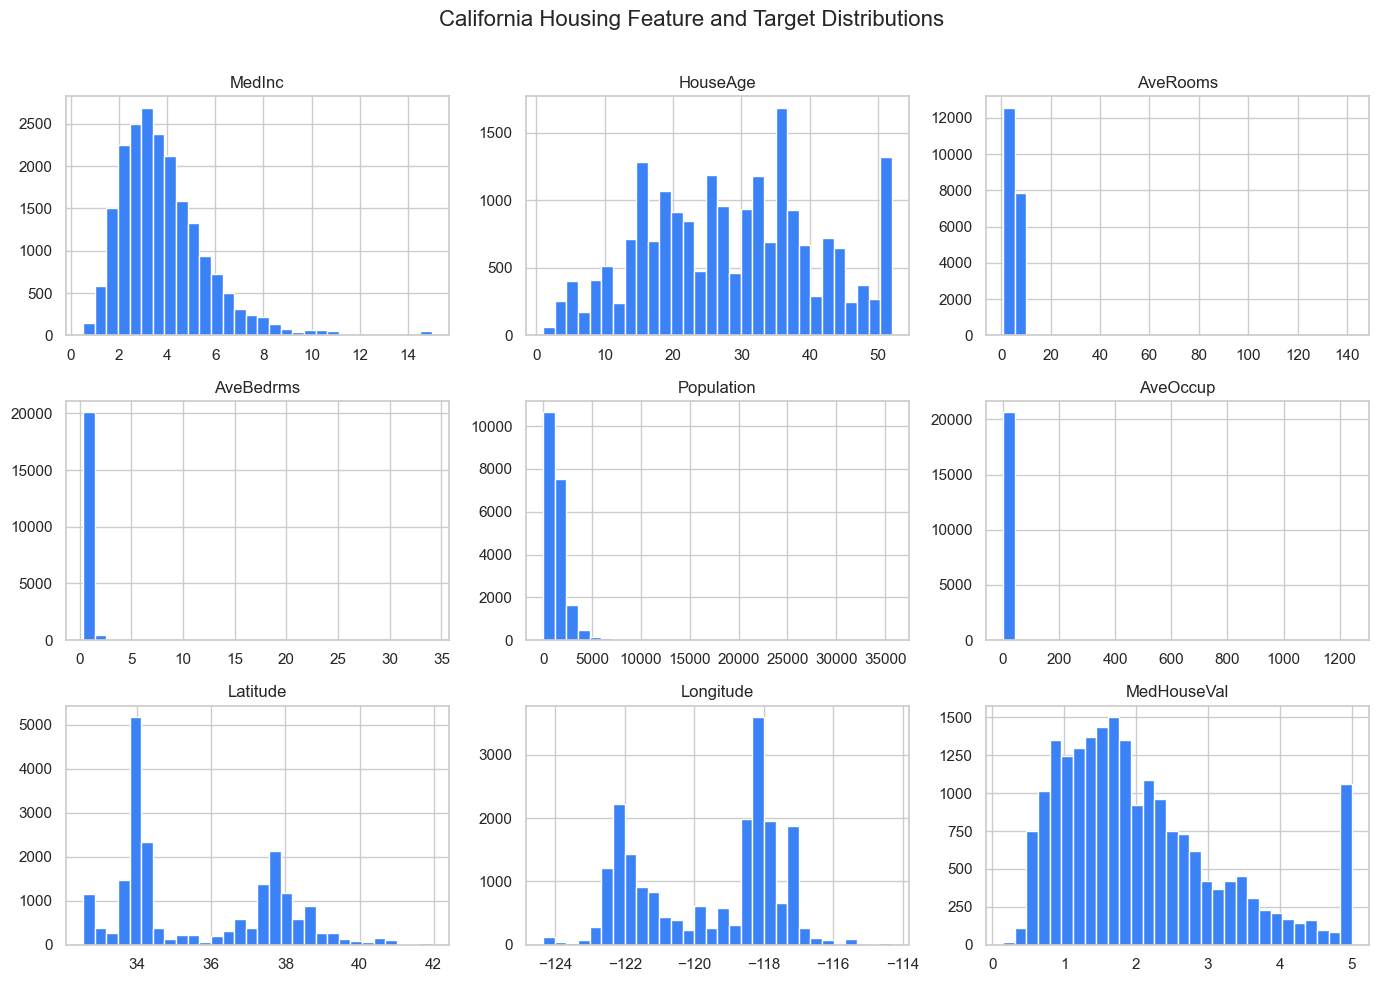

In [7]:
df.hist(figsize=(14, 10), bins=30, color="#3B82F6", edgecolor="white")
plt.suptitle("California Housing Feature and Target Distributions", fontsize=16)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig(PLOTS_DIR / "histograms.png", dpi=180, bbox_inches="tight")
plt.show()

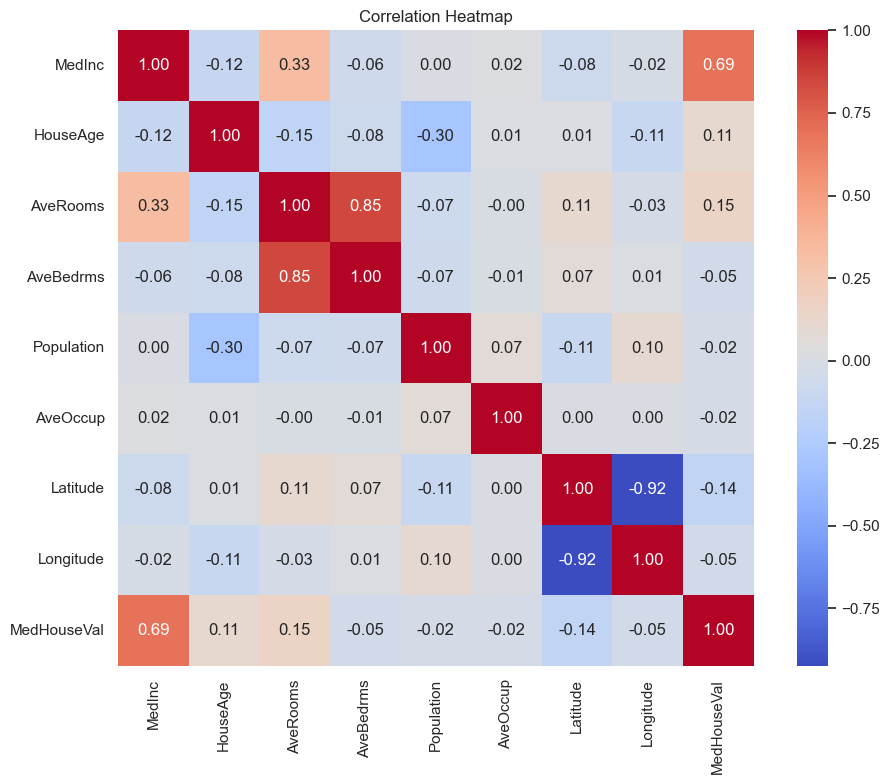

In [8]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

### Correlation Interpretation

The strongest positive correlation with `MedHouseVal` is typically `MedInc`, meaning areas with higher median income tend to have higher median house values. Latitude and longitude also show meaningful relationships because housing values vary by geography. Correlation does not prove causation, but it helps identify useful predictive features.

## Data Preparation

The feature matrix `X` contains all input columns. The target vector `y` contains `MedHouseVal`.

In [9]:
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (20640, 8)
Target vector shape: (20640,)


## Train-Test Split

The dataset is split into 80% training data and 20% testing data using `random_state=42` for reproducibility.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16512
Testing samples: 4128


## Model Training

A Linear Regression model is trained using the training dataset.

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept: {model.intercept_:.4f}")

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

coefficients

Intercept: -37.0233


,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


### Coefficient Explanation

A coefficient estimates how much the target value changes when a feature increases by one unit, assuming the other features stay constant. Positive coefficients increase the prediction, while negative coefficients decrease it. Because features use different units, coefficient size should be interpreted carefully.

## Predictions

The trained model is used to predict house values for the test set.

In [12]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Values": y_test.iloc[:10].values,
    "Predicted Values": y_pred[:10]
})

comparison

,Actual Values,Predicted Values
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


## Model Evaluation

The model is evaluated using MAE, RMSE, and R2 Score.

In [13]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.5332
Root Mean Squared Error (RMSE): 0.7456
R2 Score: 0.5758


### Metric Interpretation

- **MAE:** The model is off by about `0.5332` in target units on average. Since the target is measured in $100,000 units, this is roughly `53,320` dollars.
- **RMSE:** The RMSE is `0.7456`, which penalizes larger errors more heavily than MAE.
- **R2 Score:** The R2 score is `0.5758`, meaning the linear model explains a meaningful portion of the variation in house values, but there is room for improvement.

## Visualization

The following plots compare actual vs predicted values and examine residuals.

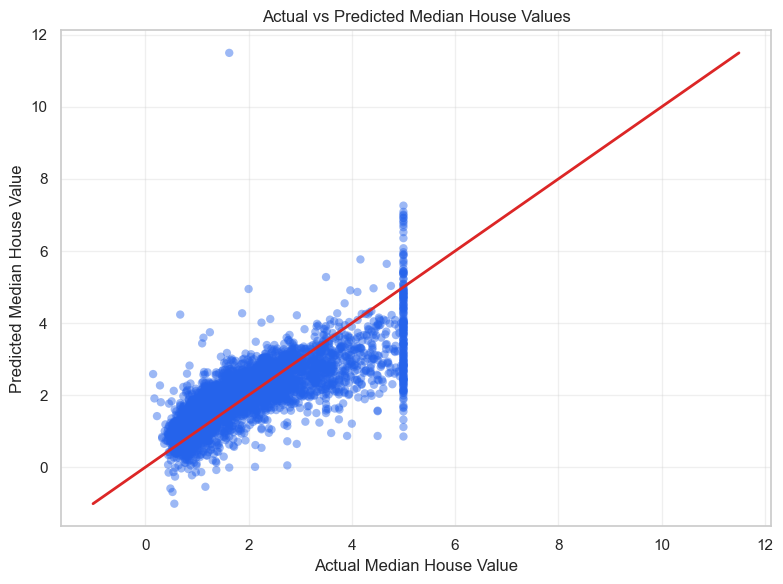

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.45, color="#2563EB", edgecolors="none")
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color="#DC2626", linewidth=2)
plt.title("Actual vs Predicted Median House Values")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "actual_vs_predicted.png", dpi=180, bbox_inches="tight")
plt.show()

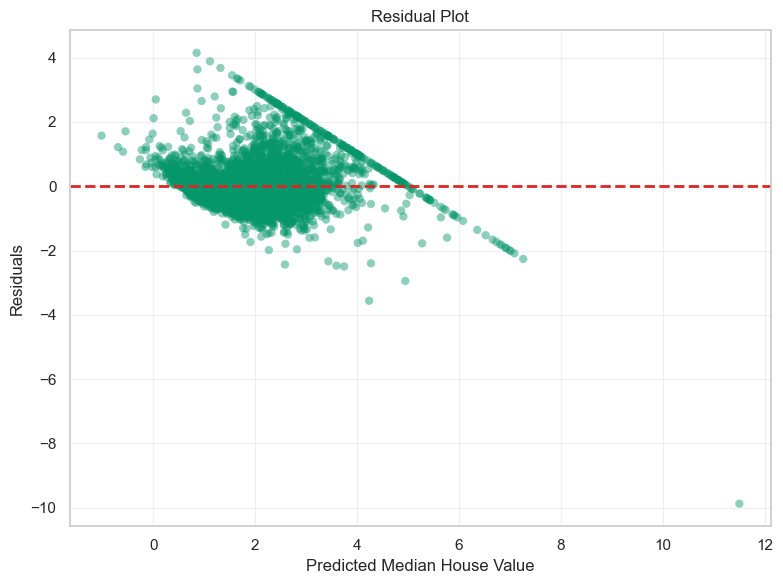

In [15]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.45, color="#059669", edgecolors="none")
plt.axhline(y=0, color="#DC2626", linestyle="--", linewidth=2)
plt.title("Residual Plot")
plt.xlabel("Predicted Median House Value")
plt.ylabel("Residuals")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "residual_plot.png", dpi=180, bbox_inches="tight")
plt.show()

### Residual Interpretation

The residuals are centered around zero, which is expected for a fitted regression model. However, the spread is not perfectly random across all predicted values. This suggests that a simple linear model is a useful baseline, but non-linear models and additional feature engineering may improve performance.

## Model Saving

The trained model is saved with pickle so it can be loaded later for inference.

In [16]:
with open("house_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("house_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

loaded_prediction = loaded_model.predict(X_test.iloc[[0]])
print(f"Loaded model sample prediction: {loaded_prediction[0]:.4f}")

Loaded model sample prediction: 0.7191


## Conclusions

The Linear Regression model successfully predicts California median house values using the provided eight numeric features. Median income is the most important positive indicator in the dataset, while geographic features also influence model behavior. The model is reproducible and suitable as a baseline regression solution.

## Future Improvements

- Compare against Ridge Regression and Lasso Regression.
- Train tree-based models such as Random Forest Regressor and Gradient Boosting Regressor.
- Use cross validation to obtain more reliable performance estimates.
- Add feature engineering, especially for location-based patterns.
- Tune hyperparameters for stronger predictive performance.